# 01 — Exploración de datos

Análisis exploratorio del dataset de cabecera del gasoducto: un mes de operación normal con muestreo cada 1 minuto, presión (P) y caudal (Q).

**Objetivo:** caracterizar la calidad y estructura de los datos, y derivar empíricamente las propiedades que justifican el diseño del detector en capas (sanidad, suavizado, divergencia P-Q, CUSUM).

**Dataset:** `data/PLOT_TS_P_Q.csv` (no versionado en el repo).

In [55]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Configuración de matplotlib
%matplotlib inline
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["figure.dpi"] = 100

# Ruta al CSV (relativa a la ubicación del notebook)
DATA_PATH = Path("..") / "data" / "PLOT_TS_P_Q.csv"
assert DATA_PATH.exists(), f"No se encuentra el CSV en {DATA_PATH.resolve()}"

print(f"CSV encontrado en: {DATA_PATH.resolve()}")
print(f"Tamaño: {DATA_PATH.stat().st_size / 1024:.1f} KB")

CSV encontrado en: C:\Users\agust\Portfolio\monitor-gasoducto\data\PLOT_TS_P_Q.csv
Tamaño: 1634.1 KB


## 1. Carga y primer vistazo

Lectura del CSV con separador `;` y separador decimal `.`. Parseo de la columna `TS` con formato `dd/mm/yyyy HH:MM:SS`. Inspección inicial de estructura, tipos y rango.

In [56]:
# Carga del CSV
df = pd.read_csv(
    DATA_PATH,
    sep=";",
    parse_dates=["TS"],
    date_format="%d/%m/%Y %H:%M:%S",
)

# Primer vistazo
print(f"Shape: {df.shape}")
print(f"\nDtypes:\n{df.dtypes}")
print(f"\nRango temporal: {df['TS'].min()}  →  {df['TS'].max()}")
print(f"\nPrimeras 5 filas:")
df.head()

Shape: (43154, 3)

Dtypes:
TS    datetime64[us]
P            float64
Q            float64
dtype: object

Rango temporal: 2026-04-09 13:47:00  →  2026-05-09 13:00:00

Primeras 5 filas:


,TS,P,Q
0,2026-04-09 13:47:00,92.74138,850.4634
1,2026-04-09 13:48:00,92.74138,850.4634
2,2026-04-09 13:49:00,92.74138,850.4634
3,2026-04-09 13:50:00,92.74138,850.4634
4,2026-04-09 13:51:00,92.74138,850.4634


## 2. Sanidad temporal

Verificación de propiedades estructurales de la serie temporal: orden, duplicados, gaps en el muestreo y valores faltantes en P/Q. Estos chequeos son precondición de todo el pipeline del detector (suavizado, derivadas, CUSUM asumen secuencia ordenada y regular).

In [57]:
# 2.1 — ¿Está ordenado cronológicamente?
is_sorted = df["TS"].is_monotonic_increasing
print(f"TS ordenado cronológicamente: {is_sorted}")

# 2.2 — ¿Hay duplicados de TS?
n_duplicados = df["TS"].duplicated().sum()
print(f"Timestamps duplicados: {n_duplicados}")

# 2.3 — ¿NaN en P o Q?
print(f"\nNaN por columna:")
print(df[["P", "Q"]].isna().sum())

# 2.4 — Análisis de la cadencia (intervalos entre muestras consecutivas)
deltas = df["TS"].diff().dropna()
print(f"\nEstadísticas de los intervalos entre muestras:")
print(f"  Mínimo:  {deltas.min()}")
print(f"  Máximo:  {deltas.max()}")
print(f"  Mediana: {deltas.median()}")
print(f"  Moda:    {deltas.mode().iloc[0]}")

# 2.5 — Distribución de los intervalos (cuántos son "anómalos")
print(f"\nIntervalos únicos y sus frecuencias (top 10):")
print(deltas.value_counts().head(10))

# 2.6 — ¿Cuántas muestras faltantes implican los gaps?
intervalo_esperado = pd.Timedelta(minutes=1)
muestras_faltantes = ((deltas - intervalo_esperado) / intervalo_esperado).clip(lower=0).sum()
print(f"\nMuestras faltantes (estimadas a partir de gaps): {int(muestras_faltantes)}")

TS ordenado cronológicamente: True
Timestamps duplicados: 0

NaN por columna:
P    0
Q    0
dtype: int64

Estadísticas de los intervalos entre muestras:
  Mínimo:  0 days 00:01:00
  Máximo:  0 days 00:01:00
  Mediana: 0 days 00:01:00
  Moda:    0 days 00:01:00

Intervalos únicos y sus frecuencias (top 10):
TS
0 days 00:01:00    43153
Name: count, dtype: int64

Muestras faltantes (estimadas a partir de gaps): 0


In [58]:
# Localización del gap único en el tiempo
intervalo_esperado = pd.Timedelta(minutes=1)
deltas = df["TS"].diff()

# Filas posteriores a un gap (delta > 1 min)
idx_post_gap = df.index[deltas > intervalo_esperado]

print(f"Cantidad de gaps detectados: {len(idx_post_gap)}")

for idx in idx_post_gap:
    ts_pre = df.loc[idx - 1, "TS"]
    ts_post = df.loc[idx, "TS"]
    duracion = ts_post - ts_pre

    # Posición relativa dentro del rango total
    ts_inicio = df["TS"].iloc[0]
    ts_fin = df["TS"].iloc[-1]
    pos_relativa = (ts_pre - ts_inicio) / (ts_fin - ts_inicio) * 100

    print(f"\nGap detectado:")
    print(f"  Último dato pre-gap : {ts_pre}")
    print(f"  Primer dato post-gap: {ts_post}")
    print(f"  Duración del gap    : {duracion}")
    print(f"  Posición relativa   : {pos_relativa:.1f}% del mes")

Cantidad de gaps detectados: 0


## 3. Distribuciones marginales

Inspección por separado de P y Q: estadísticas descriptivas (rango operativo, dispersión, percentiles) e histogramas (forma, modalidad, colas, valores anómalos). Estas propiedades determinan si la regresión Q=f(P) de la capa 2 puede modelarse como una sola relación lineal o si hay regímenes operativos distintos.

In [59]:
# Estadísticas descriptivas
print("Estadísticas descriptivas de P y Q:")
print(df[["P", "Q"]].describe())

Estadísticas descriptivas de P y Q:
                  P             Q
count  43154.000000  43154.000000
mean      87.919335    778.913056
std        7.166855    140.385328
min       65.380750      0.000000
25%       83.949910    722.161300
50%       90.323580    819.330900
75%       93.653880    866.630800
max       95.888950   1045.713000


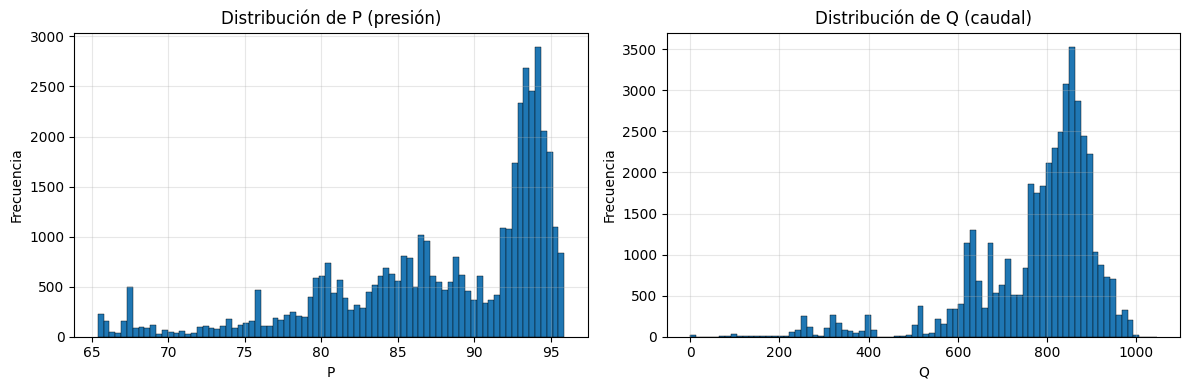

In [60]:
# Histogramas de P y Q
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["P"], bins=80, edgecolor="black", linewidth=0.3)
axes[0].set_title("Distribución de P (presión)")
axes[0].set_xlabel("P")
axes[0].set_ylabel("Frecuencia")
axes[0].grid(alpha=0.3)

axes[1].hist(df["Q"], bins=80, edgecolor="black", linewidth=0.3)
axes[1].set_title("Distribución de Q (caudal)")
axes[1].set_xlabel("Q")
axes[1].set_ylabel("Frecuencia")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Series temporales

Visualización de P y Q a lo largo del tiempo a tres escalas: mes completo (tendencias y regímenes), una semana (patrones diarios) y un día (cuantización del SCADA y variabilidad fina).

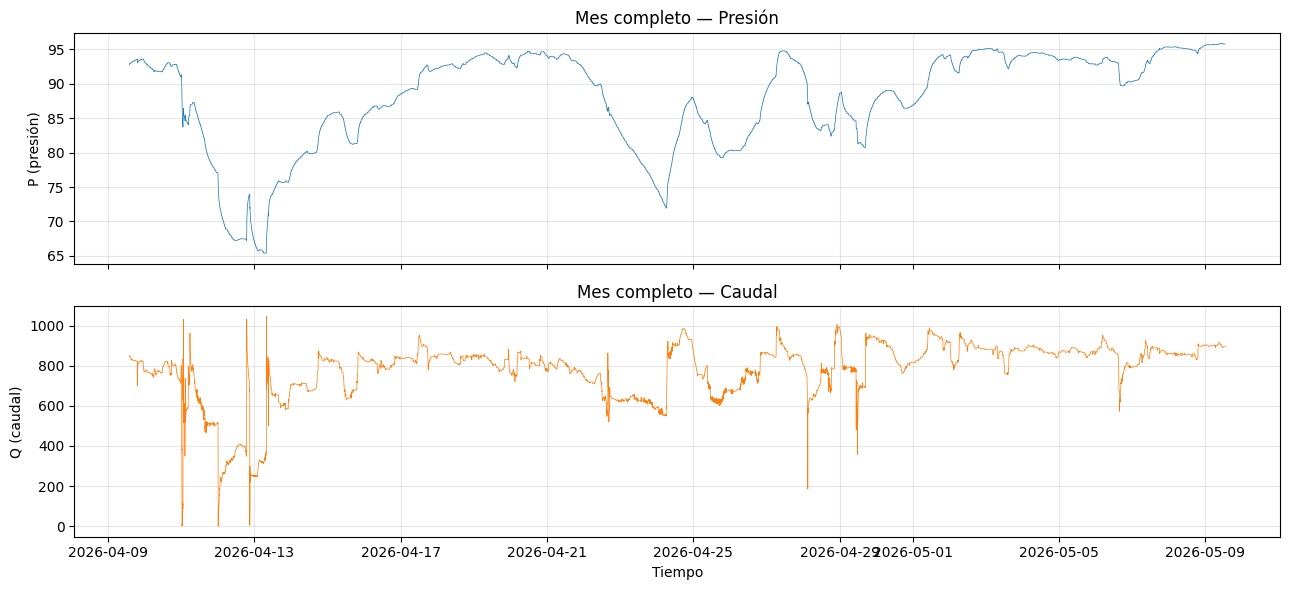

In [61]:
# 4.1 — Vista global: el mes completo
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

axes[0].plot(df["TS"], df["P"], linewidth=0.5)
axes[0].set_ylabel("P (presión)")
axes[0].set_title("Mes completo — Presión")
axes[0].grid(alpha=0.3)

axes[1].plot(df["TS"], df["Q"], linewidth=0.5, color="tab:orange")
axes[1].set_ylabel("Q (caudal)")
axes[1].set_xlabel("Tiempo")
axes[1].set_title("Mes completo — Caudal")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

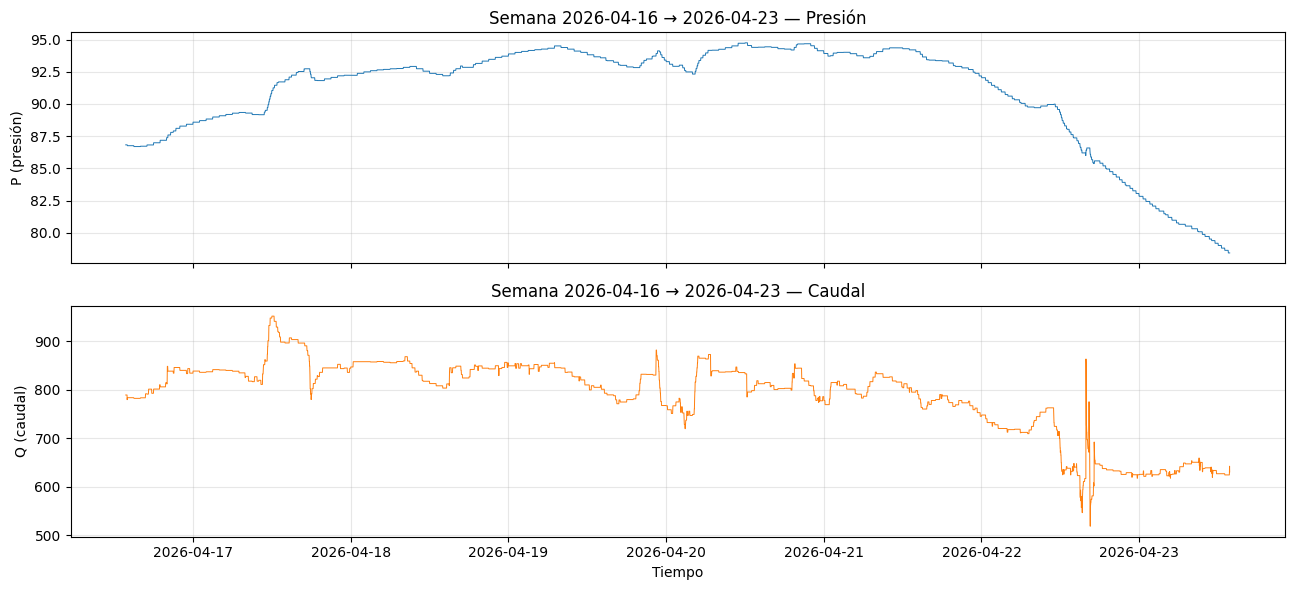

In [62]:
# 4.2 — Vista intermedia: una semana en el medio del mes
ts_inicio = df["TS"].iloc[0]
ventana_inicio = ts_inicio + pd.Timedelta(days=7)
ventana_fin = ventana_inicio + pd.Timedelta(days=7)

mascara_semana = (df["TS"] >= ventana_inicio) & (df["TS"] < ventana_fin)
df_semana = df[mascara_semana]

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

axes[0].plot(df_semana["TS"], df_semana["P"], linewidth=0.7)
axes[0].set_ylabel("P (presión)")
axes[0].set_title(f"Semana {ventana_inicio.date()} → {ventana_fin.date()} — Presión")
axes[0].grid(alpha=0.3)

axes[1].plot(df_semana["TS"], df_semana["Q"], linewidth=0.7, color="tab:orange")
axes[1].set_ylabel("Q (caudal)")
axes[1].set_xlabel("Tiempo")
axes[1].set_title(f"Semana {ventana_inicio.date()} → {ventana_fin.date()} — Caudal")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

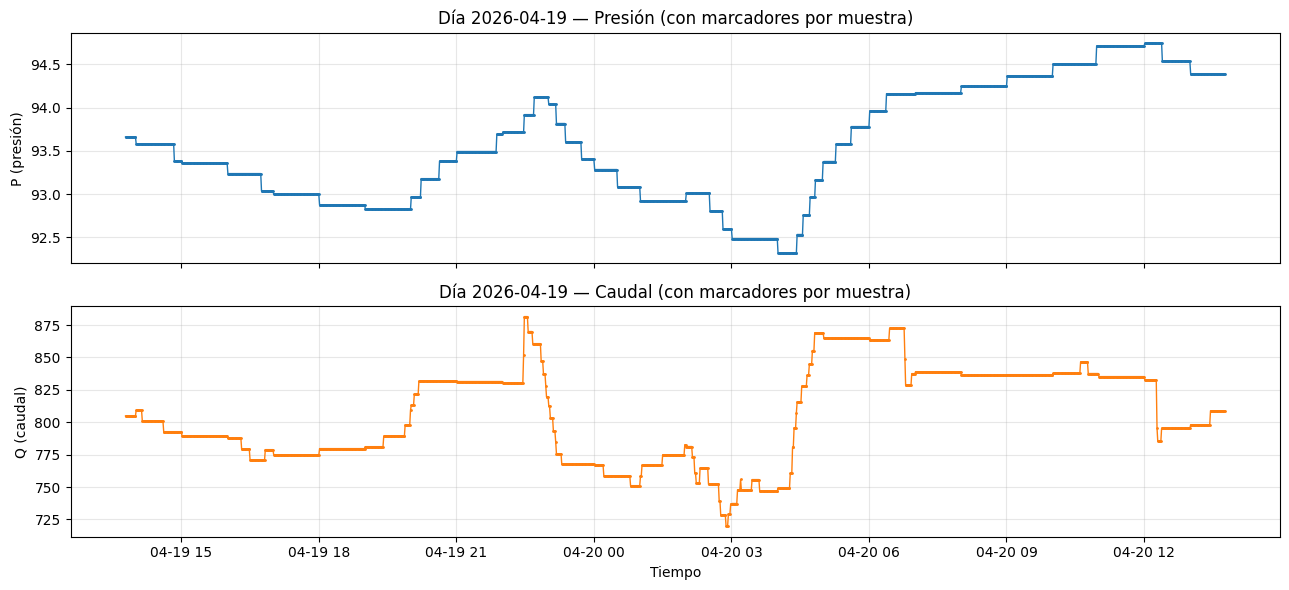

In [63]:
# 4.3 — Vista fina: un día en el medio de la semana anterior
dia_inicio = ventana_inicio + pd.Timedelta(days=3)
dia_fin = dia_inicio + pd.Timedelta(days=1)

mascara_dia = (df["TS"] >= dia_inicio) & (df["TS"] < dia_fin)
df_dia = df[mascara_dia]

fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)

axes[0].plot(df_dia["TS"], df_dia["P"], linewidth=1.0, marker=".", markersize=2)
axes[0].set_ylabel("P (presión)")
axes[0].set_title(f"Día {dia_inicio.date()} — Presión (con marcadores por muestra)")
axes[0].grid(alpha=0.3)

axes[1].plot(df_dia["TS"], df_dia["Q"], linewidth=1.0, color="tab:orange", marker=".", markersize=2)
axes[1].set_ylabel("Q (caudal)")
axes[1].set_xlabel("Tiempo")
axes[1].set_title(f"Día {dia_inicio.date()} — Caudal (con marcadores por muestra)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Relación P-Q

Análisis de la dependencia entre presión y caudal: scatter plot para inspeccionar la forma de la nube (lineal, curva, multi-modal), correlación de Pearson (relación lineal) y de Spearman (relación monótona). Esta sección determina si la regresión Q=f(P) de la capa 2 puede modelarse como una sola recta o si la estructura es más compleja.

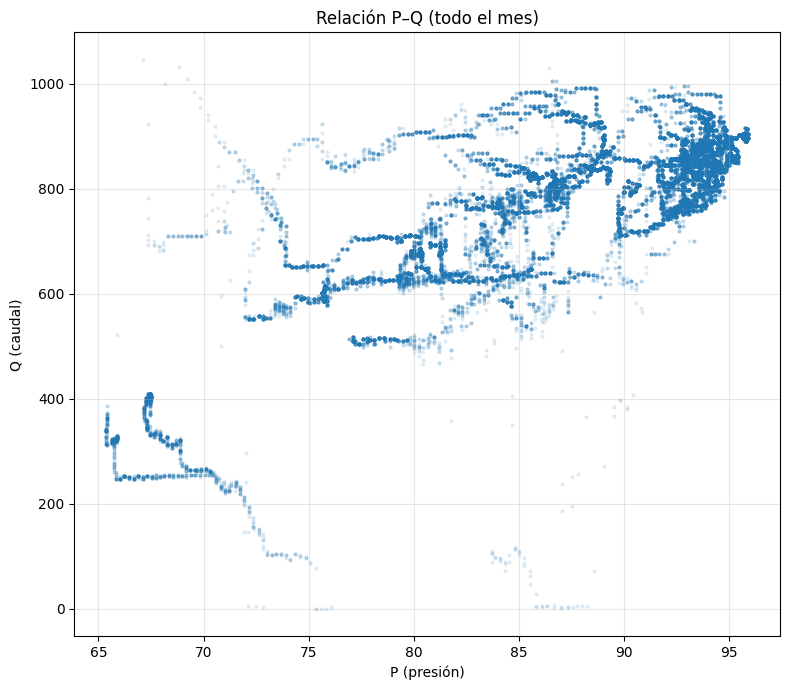

In [64]:
# Scatter plot P vs Q
fig, ax = plt.subplots(figsize=(8, 7))

ax.scatter(df["P"], df["Q"], alpha=0.1, s=4)
ax.set_xlabel("P (presión)")
ax.set_ylabel("Q (caudal)")
ax.set_title("Relación P–Q (todo el mes)")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [65]:
# Correlaciones
corr_pearson = df[["P", "Q"]].corr(method="pearson").iloc[0, 1]
corr_spearman = df[["P", "Q"]].corr(method="spearman").iloc[0, 1]

print(f"Correlación de Pearson  (lineal):   {corr_pearson:.4f}")
print(f"Correlación de Spearman (monótona): {corr_spearman:.4f}")
print(f"\nDiferencia (Spearman - Pearson):    {corr_spearman - corr_pearson:+.4f}")

Correlación de Pearson  (lineal):   0.7912
Correlación de Spearman (monótona): 0.6915

Diferencia (Spearman - Pearson):    -0.0997


## 6. Deadband del SCADA

Caracterización de la cuantización del SCADA: el sensor solo reporta cambios cuando superan un umbral mínimo (deadband), por lo que valores cuasi-constantes son la regla y los saltos discretos son la excepción. Esto invalida el uso de derivadas crudas (la mayoría serán cero) y justifica la capa 1 (suavizado) del detector.

**Dato operativo conocido:** el deadband nominal de P es 0.2.
El de Q se estima empíricamente desde los datos.

In [66]:
# Saltos minuto a minuto en P y Q (valor absoluto)
saltos_P = df["P"].diff().abs()
saltos_Q = df["Q"].diff().abs()

# Filtramos los ceros (filas sin cambio)
saltos_P_no_cero = saltos_P[saltos_P > 0]
saltos_Q_no_cero = saltos_Q[saltos_Q > 0]

total = len(df) - 1  # diff() pierde una fila

print("Frecuencia de cambio (cuantización):")
print(f"  P cambia en {len(saltos_P_no_cero):>6} de {total} filas ({100*len(saltos_P_no_cero)/total:.2f}%)")
print(f"  Q cambia en {len(saltos_Q_no_cero):>6} de {total} filas ({100*len(saltos_Q_no_cero)/total:.2f}%)")

Frecuencia de cambio (cuantización):
  P cambia en   1616 de 43153 filas (3.74%)
  Q cambia en   3480 de 43153 filas (8.06%)


In [67]:
# Estadísticas de los saltos no-cero
print("Saltos no-cero — estadísticas:")
print()
print("P:")
print(saltos_P_no_cero.describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]))
print(f"  Moda: {saltos_P_no_cero.mode().iloc[0]}")
print()
print("Q:")
print(saltos_Q_no_cero.describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]))
print(f"  Moda: {saltos_Q_no_cero.mode().iloc[0]}")

Saltos no-cero — estadísticas:

P:
count    1616.000000
mean        0.165213
std         0.094618
min         0.000070
1%          0.004802
5%          0.015948
50%         0.201370
95%         0.259062
99%         0.413515
max         1.245690
Name: P, dtype: float64
  Moda: 0.20219000000000165

Q:
count    3480.000000
mean       11.641052
std        28.400279
min         0.007000
1%          0.257101
5%          1.146313
50%         8.665000
95%        22.480680
99%        95.111201
max       728.851000
Name: Q, dtype: float64
  Moda: 1.1572999999999638


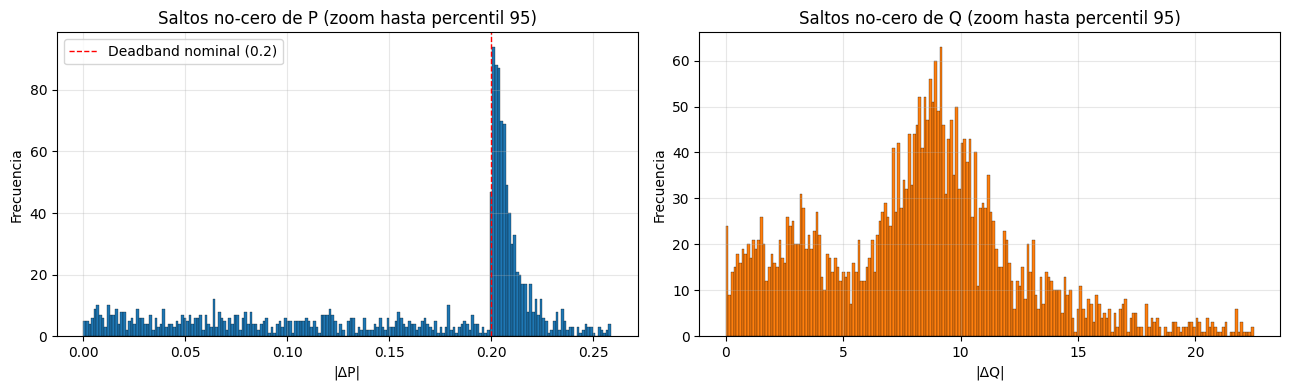

In [68]:
# Histogramas de los saltos (zoom en valores chicos donde está la cuantización)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# P: zoom hasta el percentil 95 para ver la estructura de la cuantización
p_max_plot = saltos_P_no_cero.quantile(0.95)
axes[0].hist(saltos_P_no_cero[saltos_P_no_cero <= p_max_plot], bins=200, edgecolor="black", linewidth=0.2)
axes[0].axvline(0.2, color="red", linestyle="--", linewidth=1, label="Deadband nominal (0.2)")
axes[0].set_title("Saltos no-cero de P (zoom hasta percentil 95)")
axes[0].set_xlabel("|ΔP|")
axes[0].set_ylabel("Frecuencia")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Q: zoom hasta el percentil 95
q_max_plot = saltos_Q_no_cero.quantile(0.95)
axes[1].hist(saltos_Q_no_cero[saltos_Q_no_cero <= q_max_plot], bins=200, edgecolor="black", linewidth=0.2, color="tab:orange")
axes[1].set_title("Saltos no-cero de Q (zoom hasta percentil 95)")
axes[1].set_xlabel("|ΔQ|")
axes[1].set_ylabel("Frecuencia")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [69]:
# Reporte comparativo: deadband estimado vs rango operativo
deadband_P_estimado = saltos_P_no_cero.min()
deadband_Q_estimado = saltos_Q_no_cero.min()

rango_P = df["P"].max() - df["P"].min()
rango_Q = df["Q"].max() - df["Q"].min()

print("Deadband estimado vs rango operativo:")
print(f"  P: deadband = {deadband_P_estimado:.4f} | rango = {rango_P:.2f} | relativo = {100*deadband_P_estimado/rango_P:.4f}%")
print(f"  Q: deadband = {deadband_Q_estimado:.4f} | rango = {rango_Q:.2f} | relativo = {100*deadband_Q_estimado/rango_Q:.4f}%")

print(f"\nVerificación contra dato operativo:")
print(f"  Deadband nominal de P: 0.2")
print(f"  Deadband empírico de P: {deadband_P_estimado:.4f}")
print(f"  Diferencia: {abs(deadband_P_estimado - 0.2):.4f}")

Deadband estimado vs rango operativo:
  P: deadband = 0.0001 | rango = 30.51 | relativo = 0.0002%
  Q: deadband = 0.0070 | rango = 1045.71 | relativo = 0.0007%

Verificación contra dato operativo:
  Deadband nominal de P: 0.2
  Deadband empírico de P: 0.0001
  Diferencia: 0.1999


### 6.1 — Verificación del heartbeat horario (P)

Hipótesis (confirmada operativamente por el dato del SCADA): el sensor de P aplica deadband de 0.2 pero **fuerza una actualización cada hora completa** (heartbeat al cumplirse `hh:00:00`). Esto explica los saltos no-cero menores a 0.2 observados en la sección anterior.

Verificación: medir qué fracción de los saltos pequeños (< 0.2) cae exactamente en timestamps `hh:00:00`. Si la hipótesis es correcta, esa fracción debe ser muy alta.

In [70]:
# Saltos pequeños: por debajo del deadband nominal
saltos_P_pequenos_mask = (saltos_P > 0) & (saltos_P < 0.2)
saltos_P_grandes_mask = saltos_P >= 0.2

n_pequenos = saltos_P_pequenos_mask.sum()
n_grandes = saltos_P_grandes_mask.sum()

# ¿Cuál es el TS asociado a cada salto?
# diff() le asigna el resultado a la fila n (no a la n-1), así que el TS del salto es df["TS"].iloc[n]
ts_saltos_pequenos = df.loc[saltos_P_pequenos_mask, "TS"]
ts_saltos_grandes = df.loc[saltos_P_grandes_mask, "TS"]

# ¿Cuántos caen exactamente en hh:00:00?
def es_hora_redonda(ts_series):
    return (ts_series.dt.minute == 0) & (ts_series.dt.second == 0)

pequenos_en_hora = es_hora_redonda(ts_saltos_pequenos).sum()
grandes_en_hora = es_hora_redonda(ts_saltos_grandes).sum()

print(f"Saltos pequeños (0 < |ΔP| < 0.2): {n_pequenos}")
print(f"  Caen en hh:00:00: {pequenos_en_hora} ({100*pequenos_en_hora/n_pequenos:.1f}%)")
print()
print(f"Saltos grandes (|ΔP| >= 0.2):    {n_grandes}")
print(f"  Caen en hh:00:00: {grandes_en_hora} ({100*grandes_en_hora/n_grandes:.1f}%)")
print()
print(f"Como referencia, en una distribución uniforme se esperaría que")
print(f"~{100/60:.1f}% de los timestamps cayeran en hh:00:00 (1 de cada 60 minutos).")

Saltos pequeños (0 < |ΔP| < 0.2): 710
  Caen en hh:00:00: 0 (0.0%)

Saltos grandes (|ΔP| >= 0.2):    906
  Caen en hh:00:00: 23 (2.5%)

Como referencia, en una distribución uniforme se esperaría que
~1.7% de los timestamps cayeran en hh:00:00 (1 de cada 60 minutos).


In [71]:
# Chequeo de sanidad: ¿qué timestamps tienen los saltos pequeños?
# Mostramos algunos ejemplos concretos para verificar que diff() asigna correctamente.

# Encontrar los índices de los saltos pequeños
idx_saltos_pequenos = df.index[saltos_P_pequenos_mask]

print(f"Total de saltos pequeños: {len(idx_saltos_pequenos)}")
print(f"\nPrimeros 10 ejemplos (mostrando fila previa y fila del salto):\n")

for idx in idx_saltos_pequenos[:10]:
    ts_pre = df.loc[idx - 1, "TS"]
    p_pre = df.loc[idx - 1, "P"]
    ts_post = df.loc[idx, "TS"]
    p_post = df.loc[idx, "P"]
    delta = p_post - p_pre
    print(f"  {ts_pre} (P={p_pre})  →  {ts_post} (P={p_post})  |  ΔP={delta:+.5f}")

# Distribución de los segundos en los TS de saltos pequeños
print(f"\nDistribución de minutos en TS de saltos pequeños (top 10):")
minutos_pequenos = df.loc[saltos_P_pequenos_mask, "TS"].dt.minute.value_counts().head(10)
print(minutos_pequenos)

Total de saltos pequeños: 710

Primeros 10 ejemplos (mostrando fila previa y fila del salto):

  2026-04-09 14:00:00 (P=92.94348)  →  2026-04-09 14:01:00 (P=92.99013)  |  ΔP=+0.04665
  2026-04-09 15:00:00 (P=92.99013)  →  2026-04-09 15:01:00 (P=93.16496)  |  ΔP=+0.17483
  2026-04-09 16:00:00 (P=93.16496)  →  2026-04-09 16:01:00 (P=93.26647)  |  ΔP=+0.10151
  2026-04-09 17:00:00 (P=93.26647)  →  2026-04-09 17:01:00 (P=93.41537)  |  ΔP=+0.14890
  2026-04-09 18:00:00 (P=93.41537)  →  2026-04-09 18:01:00 (P=93.53212)  |  ΔP=+0.11675
  2026-04-09 19:00:00 (P=93.53212)  →  2026-04-09 19:01:00 (P=93.58847)  |  ΔP=+0.05635
  2026-04-09 20:00:00 (P=93.28658)  →  2026-04-09 20:01:00 (P=93.38123)  |  ΔP=+0.09465
  2026-04-09 21:00:00 (P=93.38123)  →  2026-04-09 21:01:00 (P=93.51239)  |  ΔP=+0.13116
  2026-04-09 22:00:00 (P=93.51239)  →  2026-04-09 22:01:00 (P=93.60497)  |  ΔP=+0.09258
  2026-04-09 23:00:00 (P=93.60497)  →  2026-04-09 23:01:00 (P=93.5929)  |  ΔP=-0.01207

Distribución de minutos e

### 6.2 — Conclusiones de la cuantización del SCADA

**Hallazgos confirmados:**

- **P tiene cuantización por deadband nominal de 0.2** (operativamente conocido y empíricamente confirmado: moda de los saltos = 0.20).
- **El SCADA aplica heartbeat horario en P**: cada hora exacta fuerza una actualización del valor sin importar el deadband. La diferencia causada por ese heartbeat se materializa como salto pequeño (< 0.2) en el TS posterior al cambio de hora (`hh:01:00`). Verificación empírica: 704 de 710 saltos < 0.2 (99.2%) caen exactamente en `:01:00`, frente a 1.67% esperado bajo distribución uniforme.
- **Q no presenta cuantización SCADA detectable**: su distribución de saltos es continua sin pico dominante ni evidencia de heartbeat. La estabilidad inter-muestral de Q proviene de la física del flujo (caudal real estable durante minutos), no de filtrado del sensor.

**Implicaciones para el detector (capa 1 — suavizado):**

- **Ventana de suavizado ≥ 1 hora** es necesaria para absorber el heartbeat horario de P. Una ventana menor dejaría el heartbeat visible como pulso periódico en la señal suavizada, generando falsas alarmas de divergencia.
- **Ventana propuesta: 2 horas (120 muestras)** — cubre al menos un heartbeat completo con margen, y promedia suficientes saltos de deadband (~7 saltos típicos por ventana, dado que P cambia en 3.7% de las filas).
- El parámetro exacto se ajustará empíricamente en el notebook 02 sobre la base de este límite inferior.

## 7. Glitches físicos

Lecturas de Q ≈ 0 con P en rango operativo normal son físicamente imposibles: si el gasoducto está presurizado, hay caudal. Estas filas son errores de telemetría del SCADA y deben ser descartadas en la capa 0 (sanidad) antes de cualquier procesamiento.

Caracterización: cantidad, contexto (valor de P asociado) y distribución temporal.

In [72]:
# Filas con Q exactamente igual a 0
glitches_mask = df["Q"] == 0
n_glitches = glitches_mask.sum()

print(f"Filas con Q = 0: {n_glitches} de {len(df)} ({100*n_glitches/len(df):.4f}%)")

if n_glitches > 0:
    glitches = df[glitches_mask]
    print(f"\nP asociado a las filas con Q = 0:")
    print(glitches["P"].describe())
    print(f"\nDetalle de las filas con Q = 0:")
    print(glitches.to_string())

Filas con Q = 0: 4 de 43154 (0.0093%)

P asociado a las filas con Q = 0:
count     4.000000
mean     75.526832
std       0.214371
min      75.362690
25%      75.362690
50%      75.465500
75%      75.629643
max      75.813640
Name: P, dtype: float64

Detalle de las filas con Q = 0:
                      TS         P    Q
3500 2026-04-12 00:07:00  75.81364  0.0
3501 2026-04-12 00:08:00  75.56831  0.0
3502 2026-04-12 00:09:00  75.36269  0.0
3503 2026-04-12 00:10:00  75.36269  0.0


In [73]:
# Distribución temporal de los glitches
if n_glitches > 0:
    # ¿Están concentrados o dispersos?
    ts_glitches = df.loc[glitches_mask, "TS"].sort_values()
    gaps_entre_glitches = ts_glitches.diff().dropna()

    print("Distribución temporal de los glitches:")
    print(f"  Primer glitch:    {ts_glitches.iloc[0]}")
    print(f"  Último glitch:    {ts_glitches.iloc[-1]}")
    print(f"  Span temporal:    {ts_glitches.iloc[-1] - ts_glitches.iloc[0]}")
    print(f"\nIntervalos entre glitches consecutivos:")
    print(gaps_entre_glitches.to_string())

Distribución temporal de los glitches:
  Primer glitch:    2026-04-12 00:07:00
  Último glitch:    2026-04-12 00:10:00
  Span temporal:    0 days 00:03:00

Intervalos entre glitches consecutivos:
3501   0 days 00:01:00
3502   0 days 00:01:00
3503   0 days 00:01:00


### Conclusiones de la Sección 7

**Caracterización de los glitches:**
- Cantidad: 4 filas con Q = 0 (0.009 % del dataset).
- **No están dispersos:** ocurren en 4 minutos consecutivos (12-abr 00:07:00 → 00:10:00).
- Ocurren con P ≈ 75 (sistema presurizado): **Q = 0 con P = 75 es físicamente imposible**, son errores de telemetría.
- Coinciden temporalmente con un período de operación atípica del gasoducto (gran valle de presión del 11–16 de abril visto en Sección 4).

**Regla para la capa 0 (sanidad) del detector:**
Descartar filas donde `Q == 0` y `P > 50`. Umbral conservador: 50 está bien por debajo del mínimo operativo observado (65), y permite que en el futuro el sistema apagado real (P ≈ 0, Q ≈ 0) no sea filtrado por error.

In [74]:
# Aplicación de la regla de sanidad: descartar Q=0 con sistema presurizado
df_clean = df[~((df["Q"] == 0) & (df["P"] > 50))].reset_index(drop=True)

print(f"Filas antes del filtro:  {len(df):>6}")
print(f"Filas después del filtro:{len(df_clean):>6}")
print(f"Filas descartadas:       {len(df) - len(df_clean):>6}")

# Verificación
assert (df_clean["Q"] != 0).all() or (df_clean.loc[df_clean["Q"] == 0, "P"] <= 50).all(), \
    "El filtro no eliminó todos los glitches"
print("\n✓ Filtro aplicado correctamente: no quedan filas con Q=0 y P>50 en df_clean")

Filas antes del filtro:   43154
Filas después del filtro: 43150
Filas descartadas:            4

✓ Filtro aplicado correctamente: no quedan filas con Q=0 y P>50 en df_clean


## 8. Conclusiones consolidadas

### Calidad del dataset

- **43.150 filas** efectivas (post-saneamiento), del 9-abr al 9-may de 2026.
- **Cadencia perfectamente regular** de 1 minuto, sin gaps ni timestamps duplicados.
- **Sin NaN** en P ni Q.
- **4 glitches** físicamente imposibles (Q=0 con P≈75) detectados y eliminados; ocurren en 4 minutos consecutivos durante un período de operación atípica del gasoducto.

### Estructura del SCADA

- **P presenta cuantización fuerte:** deadband nominal de 0.2 (confirmado empíricamente, moda = 0.2022) más un heartbeat horario que fuerza una actualización en cada `hh:01:00`. Solo el 3.74 % de las filas registra un cambio en P.
- **Q no presenta cuantización SCADA detectable:** distribución de saltos continua sin pico dominante. Su estabilidad inter-muestral proviene de la física del flujo, no del filtrado del sensor. El 8.06 % de las filas registra un cambio en Q.
- **Implicación:** las derivadas crudas son insuficientes para análisis. La capa 1 (suavizado) debe usar una ventana que absorba al menos un ciclo de heartbeat completo.

### Dinámica P-Q

- **Correlación moderada-fuerte:** Pearson = 0.7912, Spearman = 0.6915. La relación es predominantemente lineal pero con dispersión importante.
- **Múltiples regímenes operativos:** los histogramas marginales de P y Q son multimodales, y el scatter P-Q muestra estructuras separadas (un blob denso en operación alta, un brazo descendente en operación a baja presión, bandas horizontales en Q).
- **Firma física del cierre de válvula:** P sube + Q baja (o se mantiene). Esto se traduce, en términos del modelo Q=f(P), en un **residual fuertemente negativo y sostenido en el tiempo**.

### Implicaciones para el diseño del detector

| Capa | Decisión derivada del análisis |
|---|---|
| **0 — Sanidad** | Descartar filas donde `Q = 0` y `P > 50`. |
| **1 — Suavizado** | Ventana ≥ 2 horas (cubre el heartbeat horario con margen y promedia múltiples saltos de deadband). El parámetro exacto se calibra en notebook 02. |
| **2 — Divergencia** | Regresión lineal Q = f(P) entrenada sobre el dataset saneado completo (excluye sólo glitches). Justificación: la firma física del cierre se detecta por residual negativo, no por valor absoluto; entrenar sobre todos los regímenes legítimos preserva esa firma. |
| **3 — Cambio de régimen** | **CUSUM unilateral negativo**. Solo dispara cuando el residual cae sostenidamente bajo un umbral. La direccionalidad está justificada por la firma física asimétrica del cierre. |

### Preguntas abiertas (a resolver en notebook 02)

- **¿La dispersión del scatter P-Q permite detectar cierres realistas?** La nube tiene 100–200 unidades de espesor en Q a P fijo. Un cierre que provoque un residual de 50 unidades podría quedar enmascarado por el ruido natural del modelo global. La **validación por fault injection** sobre el dataset real va a determinar la sensibilidad efectiva del detector.
- **¿Los regímenes operativos atípicos (valles de baja presión del 11–16 abril y el 24–29 abril) son legítimos o son eventos a tratar?** Las instrucciones del proyecto los anuncian como "operación normal", pero su firma en el scatter es estructuralmente distinta a la del blob denso. Si la regresión global resulta insuficiente, una alternativa es **acotar el modelo** al régimen denso y tratar los demás regímenes como condiciones "no monitoreables" (warning, no alerta).
- **¿La asimetría del CUSUM unilateral es suficiente, o conviene complementarla con otras señales?** La firma "P sube + Q baja" es la del cierre aguas arriba; aguas abajo es "ambos caen". El detector actual mira solo cabecera, lo que en principio cubre el primer caso. Detectar cierres aguas abajo desde cabecera requeriría señales más sutiles.